# Customer Churn Prediction System
### End-to-End Data Science Capstone Project

Author: Dhanashree Tankar

## Business Problem

Customer churn is a major issue in subscription-based industries such as telecommunications.  
Acquiring new customers costs significantly more than retaining existing ones. Therefore, predicting which customers are likely to leave helps organizations implement targeted retention strategies.

## Dataset Description

The dataset contains **500 customer records** with attributes describing customer behavior and subscription details.

Key features include:

- **Tenure** – number of months the customer has stayed
- **MonthlyCharges** – monthly subscription fee
- **TotalCharges** – total amount billed
- **Contract** – contract type
- **PaymentMethod** – payment type
- **PaperlessBilling** – billing preference
- **SeniorCitizen** – demographic feature
- **Churn** – target variable (1 = churn, 0 = stay)

## Project Objectives

- Perform exploratory data analysis to understand churn patterns
- Engineer meaningful features
- Train and evaluate machine learning models
- Deploy a churn prediction model
- Provide actionable business insights

## Success Metrics

- Accuracy ≥ 85%
- ROC-AUC ≥ 0.80
- High recall for churn class

# 1. IMPORT LIBRARIES

In [76]:
# ------------------------------------------------------------
# Standard Libraries
# ------------------------------------------------------------
import os
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Data Libraries
# ------------------------------------------------------------
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ------------------------------------------------------------
# Machine Learning
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ------------------------------------------------------------
# Project Modules
# ------------------------------------------------------------
from src.data_loader import load_csv, save_csv
from src.preprocessing import preprocess_dataset
from src.feature_engineering import create_features
from src.model_training import tune_model, train_model, save_model
from src.evaluation import evaluate_model

# 2. CONFIGURATION SECTION

In [77]:
class Config:
    
    RAW_DATA_PATH = "data/raw/customer_churn.csv"
    
    PROCESSED_DATA_PATH = "data/processed/cleaned_data.csv"
    
    MODEL_PATH = "deployment/model.pkl"
    
    TEST_SIZE = 0.2
    
    RANDOM_STATE = 42


config = Config()

# 3. DATA LOADING

In [78]:
df = load_csv(config.RAW_DATA_PATH)

df.head()

INFO:src.data_loader:Dataset loaded successfully
INFO:src.data_loader:Shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


# 4. DATA OVERVIEW

In [79]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

# DATA VALIDATION

In [80]:
# Validate target variable
assert df["Churn"].isin([0,1]).all(), "Churn column must contain only 0 and 1 (binary)"

# Validate numeric columns
numeric_cols = ["Tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_cols:
    assert pd.api.types.is_numeric_dtype(df[col])

print("Data validation passed")

Data validation passed


# 5. EXPLORATORY DATA ANALYSIS

Target Distribution

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


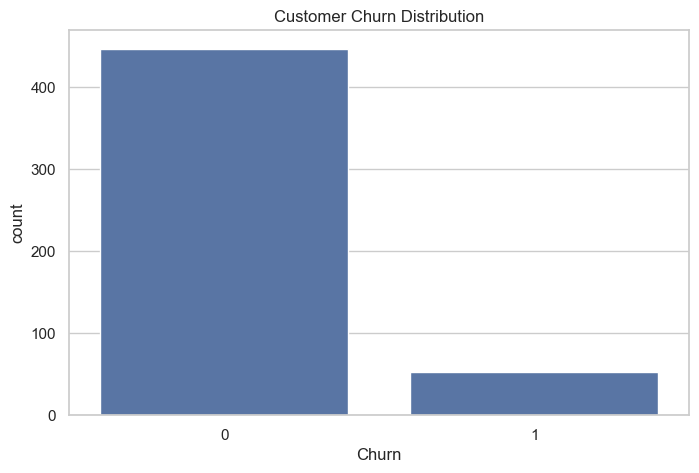

In [81]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

Churn by Contract Type

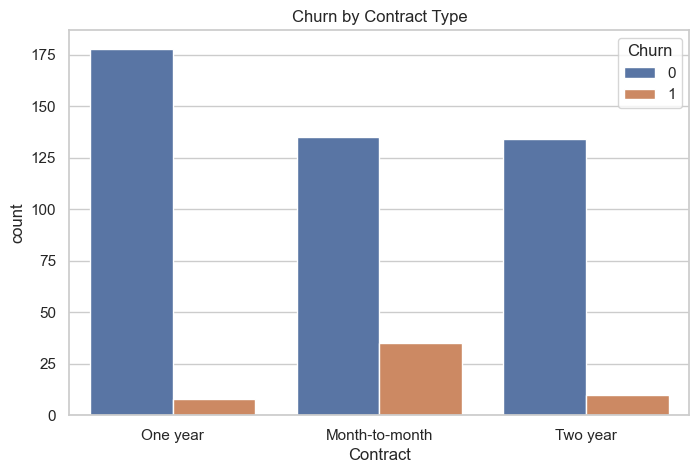

In [82]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")

plt.show()

In [ ]:
Monthly Charges vs Churn

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


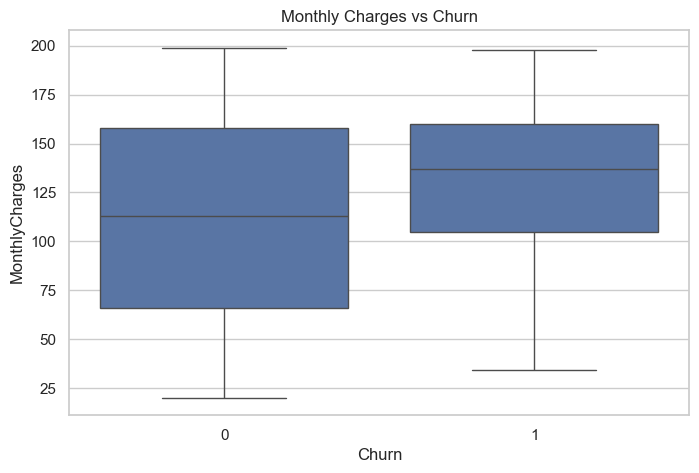

In [83]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

In [ ]:
Tenure vs Churn

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


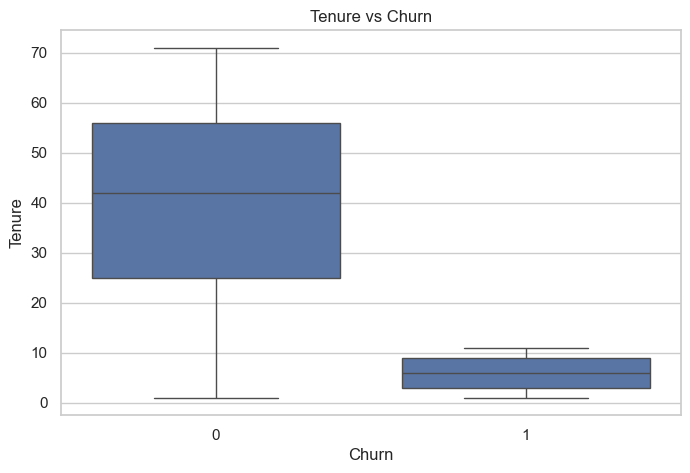

In [84]:
sns.boxplot(x="Churn", y="Tenure", data=df)

plt.title("Tenure vs Churn")

plt.show()

Correlation Heatmap

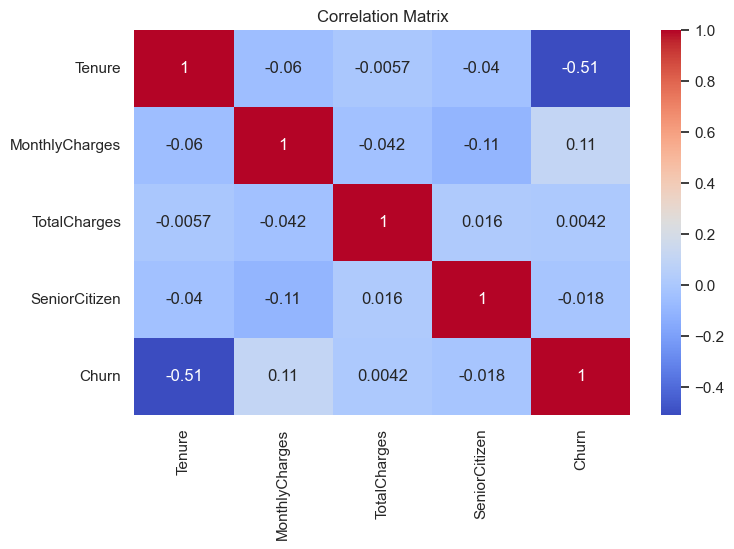

In [85]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# 6. DATA PREPROCESSING

In [91]:
logger.info("Starting preprocessing pipeline")

df_processed = preprocess_dataset(df)

logger.info("Preprocessing completed")

logger.info(f"Processed dataset shape: {df_processed.shape}")

save_csv(df_processed, config.PROCESSED_DATA_PATH)

logger.info("Processed dataset saved")

X, y = create_features(df_processed)

# ---------------------------------------------------------
# Feature Type Cleaning
# ---------------------------------------------------------

# Remove identifier column if present
if "CustomerID" in X.columns:
    X = X.drop(columns=["CustomerID"])

# Convert boolean columns to integers
bool_cols = X.select_dtypes(include="bool").columns

if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

# Final validation
non_numeric = X.select_dtypes(exclude=["number"])

if len(non_numeric.columns) > 0:
    raise ValueError(
        f"Non-numeric columns detected: {list(non_numeric.columns)}"
    )

print("Feature validation passed")

logger.info(f"Feature matrix shape: {X.shape}")

logger.info(f"Target vector shape: {y.shape}")

print("Preprocessing pipeline executed successfully")

INFO:__main__:Starting preprocessing pipeline
INFO:__main__:Preprocessing completed
INFO:__main__:Processed dataset shape: (500, 11)
INFO:src.data_loader:Dataset saved at data/processed/cleaned_data.csv
INFO:__main__:Processed dataset saved
INFO:src.feature_engineering:Feature engineering completed
INFO:src.feature_engineering:Feature matrix shape: (500, 10)
INFO:__main__:Feature matrix shape: (500, 9)
INFO:__main__:Target vector shape: (500,)


Feature validation passed
Preprocessing pipeline executed successfully


In [92]:
print(X.dtypes)

Tenure                            int64
MonthlyCharges                    int64
TotalCharges                      int64
PaperlessBilling                  int64
SeniorCitizen                     int64
Contract_One year                 int32
Contract_Two year                 int32
PaymentMethod_Credit Card         int32
PaymentMethod_Electronic Check    int32
dtype: object


# 7. TRAIN TEST SPLIT

In [93]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
    stratify=y
)

# 8. MODEL PIPELINES

In [94]:
models = {

    "Logistic Regression":

    Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Random Forest":

    Pipeline([
        ("model", RandomForestClassifier(
            random_state=config.RANDOM_STATE
        ))
    ])
}

# 9. BASELINE MODEL COMPARISON

In [95]:
results = []

for name, model in models.items():

    trained_model = train_model(model, X_train, y_train)

    metrics = evaluate_model(trained_model, X_test, y_test)

    results.append({

        "Model": name,
        "Accuracy": metrics["accuracy"],
        "ROC_AUC": metrics["roc_auc"]
    })

pd.DataFrame(results)

INFO:src.model_training:Training model
INFO:src.model_training:Model training completed
INFO:src.evaluation:Model evaluation completed
INFO:src.model_training:Training model
INFO:src.model_training:Model training completed
INFO:src.evaluation:Model evaluation completed


,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.95,0.979571
1,Random Forest,0.96,0.987743


# 9. HYPERPARAMETER TUNING

In [96]:
param_grid = {

    "model__n_estimators":[100,200,300],
    "model__max_depth":[5,10,15]
}

best_model = tune_model(

    models["Random Forest"],
    param_grid,
    X_train,
    y_train
)

INFO:src.model_training:Starting hyperparameter tuning
INFO:src.model_training:Best parameters: {'model__max_depth': 15, 'model__n_estimators': 100}


# 10. MODEL EVALUATION

In [97]:
metrics = evaluate_model(best_model, X_test, y_test)

print("Accuracy:", metrics["accuracy"])

print("ROC AUC:", metrics["roc_auc"])

print(metrics["classification_report"])

INFO:src.evaluation:Model evaluation completed


Accuracy: 0.96
ROC AUC: 0.9877425944841676
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        89
           1       1.00      0.64      0.78        11

    accuracy                           0.96       100
   macro avg       0.98      0.82      0.88       100
weighted avg       0.96      0.96      0.96       100



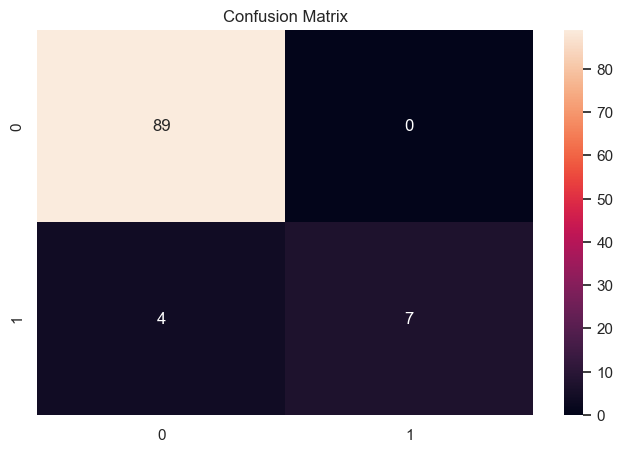

In [98]:
predictions = best_model.predict(X_test)

cm = confusion_matrix(y_test,predictions)

sns.heatmap(cm,annot=True,fmt="d")

plt.title("Confusion Matrix")

plt.show()

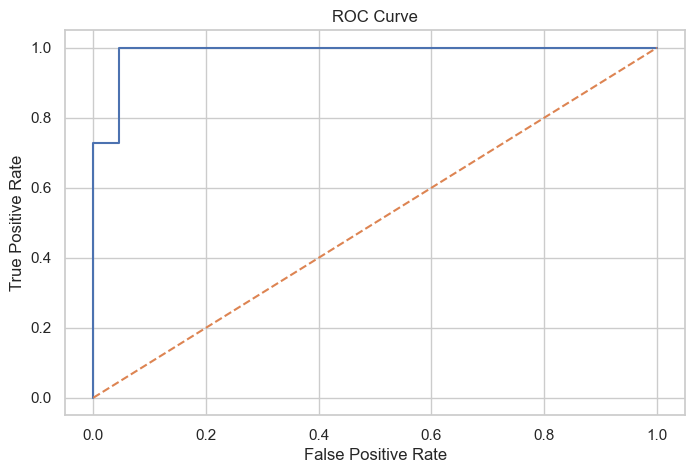

In [99]:
probabilities = best_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,probabilities)

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1],linestyle="--")

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

# 11. FEATURE IMPORTANCE

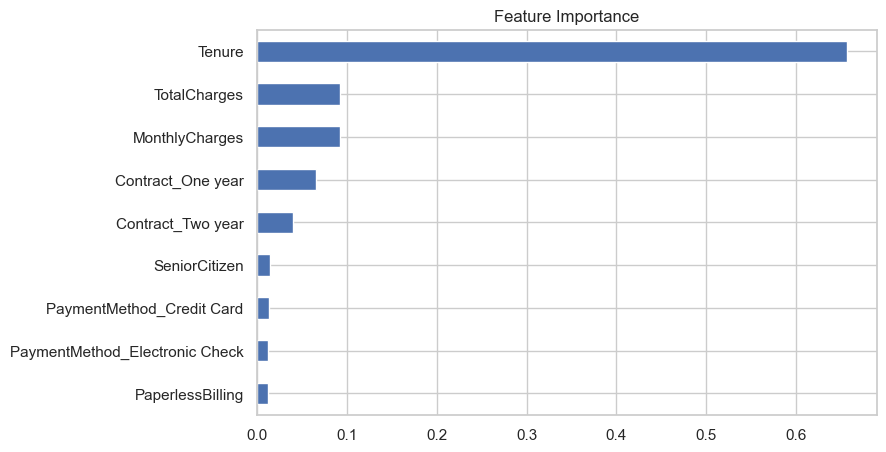

In [100]:
rf_model = best_model.named_steps["model"]

importances = pd.Series(

    rf_model.feature_importances_,

    index=X.columns

)

importances.sort_values().plot.barh()

plt.title("Feature Importance")

plt.show()

# 12. SAVE MODEL

In [101]:
save_model(best_model, config.MODEL_PATH)

print("Model saved successfully")

INFO:src.model_training:Model saved to deployment/model.pkl


Model saved successfully


# 12. EXAMPLE PREDICTION

In [106]:
sample = X_test.iloc[:1]

display(sample)

prediction = best_model.predict(sample)[0]

churn_probability = best_model.predict_proba(sample)[0][1]

print("Prediction:", "Churn" if prediction==1 else "No Churn")

print("Churn Probability:", f"{churn_probability*100:.2f}%")

,Tenure,MonthlyCharges,TotalCharges,PaperlessBilling,SeniorCitizen,Contract_One year,Contract_Two year,PaymentMethod_Credit Card,PaymentMethod_Electronic Check
58,36,38,3792,1,1,1,0,0,0


Prediction: No Churn
Churn Probability: 0.00%


In [107]:
probs = best_model.predict_proba(X_test)[:,1]

risk_df = X_test.copy()
risk_df["Churn_Risk"] = probs

risk_df.sort_values("Churn_Risk", ascending=False).head(10)

,Tenure,MonthlyCharges,TotalCharges,PaperlessBilling,SeniorCitizen,Contract_One year,Contract_Two year,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,Churn_Risk
216,10,152,5250,1,1,0,0,1,0,0.92
270,8,160,7182,0,1,0,0,0,0,0.90
54,9,157,7022,0,0,0,0,0,0,0.88
106,3,59,7111,1,1,0,0,1,0,0.83
487,9,72,2417,1,1,0,0,0,1,0.80
131,3,79,891,0,1,0,0,1,0,0.64
18,7,156,5389,1,0,1,0,0,0,0.57
171,10,115,3717,1,0,1,0,0,1,0.42
294,6,59,6657,0,0,0,1,1,0,0.38
367,10,81,5158,1,1,1,0,0,1,0.37


## Key Insights

1. Customers with **month-to-month contracts churn significantly more**
2. Customers with **higher monthly charges show higher churn probability**
3. Customers with **long tenure are less likely to churn**

## Business Recommendations

- Offer discounts for long-term contracts
- Provide loyalty rewards for long-tenure customers
- Target high-risk customers with retention campaigns

## Conclusion

This project demonstrates a complete end-to-end data science workflow:

- Data exploration and visualization
- Feature engineering
- Machine learning pipeline development
- Hyperparameter tuning
- Model evaluation
- Model deployment preparation

The final Random Forest model achieved strong predictive performance and can help telecom companies proactively reduce churn and improve customer retention strategies.